# 03 — Geometric Evaluation: Análisis Profundo de los 4 Bloques

Visualización detallada de cada bloque de evaluación:
- Bloque A: CosineDrift, RRE
- Bloque B: CKA, ρ_sim, Alignment, Uniformity
- Bloque C: Overlap@k
- Bloque D: IsoMean, EDim

In [ ]:
import sys
sys.path.insert(0, '../src')

import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from geoquant.evaluation.embeddings import load_embeddings

results_dir = Path('../outputs/results')
emb_dir     = Path('../outputs/embeddings')

# Métricas pre-calculadas (notebook 02)
with open(results_dir / 'eval_ptq.json') as f:
    results_ptq = json.load(f)

with open(results_dir / 'eval_qat.json') as f:
    results_qat = json.load(f)

# Embeddings (opcionales, para análisis adicional)
emb_fp32 = emb_ptq = emb_qat = labels = None
if (emb_dir / 'emb_fp32.pt').exists():
    emb_fp32, labels = load_embeddings(emb_dir / 'emb_fp32.pt')
    emb_ptq, _       = load_embeddings(emb_dir / 'emb_ptq.pt')
    emb_qat, _       = load_embeddings(emb_dir / 'emb_qat.pt')

print('Resultados y embeddings cargados correctamente.')

In [ ]:
# Comparativa visual de métricas clave
blocks = ['block_a', 'block_b', 'block_c', 'block_d']
fig, axes = plt.subplots(1, len(blocks), figsize=(16, 4))

for ax, block in zip(axes, blocks):
    metrics_ptq = results_ptq.get(block, {})
    metrics_qat = results_qat.get(block, {})
    names = list(metrics_ptq.keys())
    vals_ptq = [metrics_ptq[n] for n in names]
    vals_qat = [metrics_qat.get(n, 0) for n in names]

    x = np.arange(len(names))
    ax.bar(x - 0.2, vals_ptq, 0.4, label='PTQ')
    ax.bar(x + 0.2, vals_qat, 0.4, label='QAT')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
    ax.set_title(block.replace('_', ' ').title())
    ax.legend(fontsize=8)

plt.suptitle('Comparativa Geométrica: PTQ vs QAT', fontsize=14)
plt.tight_layout()
plt.show()

# PRUEBAS BLOQUE A

In [5]:
import torch
emb_base_line = torch.load("../outputs/embeddings/emb_fp32.pt", map_location="cpu")

In [6]:
emb_ptq = torch.load("../outputs/embeddings/emb_ptq.pt", map_location="cpu")
emb_qat = torch.load("../outputs/embeddings/emb_qat.pt", map_location="cpu")

In [7]:
emb_base_line = emb_base_line['embeddings']
emb_ptq = emb_ptq['embeddings']
emb_qat = emb_qat['embeddings']

## Base Line vs PTQ

In [10]:
from src.geoquant.evaluation.block_a import run

results = run(emb_base_line, emb_ptq)

cos_drift_mean = results["cosine_drift"]
cos_sim = results["cosine_similarity_per_sample"].cpu().numpy()
cos_drift = results["cosine_drift_per_sample"].cpu().numpy()
angle_deg = results["angular_separation_per_sample_deg"].cpu().numpy()

print("=== Bloque A ===")
print(f"Cosine Drift medio: {cos_drift_mean:.6f}")
print(f"Cosine similarity media: {cos_sim.mean():.6f}")
print(f"Ángulo medio (grados): {angle_deg.mean():.6f}")

=== Bloque A ===
Cosine Drift medio: 0.000078
Cosine similarity media: 0.999922
Ángulo medio (grados): 0.707053


In [11]:
import numpy as np

In [12]:
print("\n=== Resumen estadístico del Cosine Drift ===")
print(f"Min:      {cos_drift.min():.6f}")
print(f"P25:      {np.percentile(cos_drift, 25):.6f}")
print(f"Mediana:  {np.median(cos_drift):.6f}")
print(f"P75:      {np.percentile(cos_drift, 75):.6f}")
print(f"P90:      {np.percentile(cos_drift, 90):.6f}")
print(f"P95:      {np.percentile(cos_drift, 95):.6f}")
print(f"P99:      {np.percentile(cos_drift, 99):.6f}")
print(f"Max:      {cos_drift.max():.6f}")
print(f"Std:      {cos_drift.std():.6f}")

print("\n=== Resumen estadístico del ángulo (grados) ===")
print(f"Min:      {angle_deg.min():.6f}")
print(f"P25:      {np.percentile(angle_deg, 25):.6f}")
print(f"Mediana:  {np.median(angle_deg):.6f}")
print(f"P75:      {np.percentile(angle_deg, 75):.6f}")
print(f"P90:      {np.percentile(angle_deg, 90):.6f}")
print(f"P95:      {np.percentile(angle_deg, 95):.6f}")
print(f"P99:      {np.percentile(angle_deg, 99):.6f}")
print(f"Max:      {angle_deg.max():.6f}")
print(f"Std:      {angle_deg.std():.6f}")


=== Resumen estadístico del Cosine Drift ===
Min:      0.000031
P25:      0.000061
Mediana:  0.000074
P75:      0.000089
P90:      0.000108
P95:      0.000121
P99:      0.000158
Max:      0.000351
Std:      0.000024

=== Resumen estadístico del ángulo (grados) ===
Min:      0.453703
P25:      0.634890
Mediana:  0.696331
P75:      0.765150
P90:      0.841397
P95:      0.891828
P99:      1.018425
Max:      1.518009
Std:      0.104197


In [13]:
import matplotlib.pyplot as plt

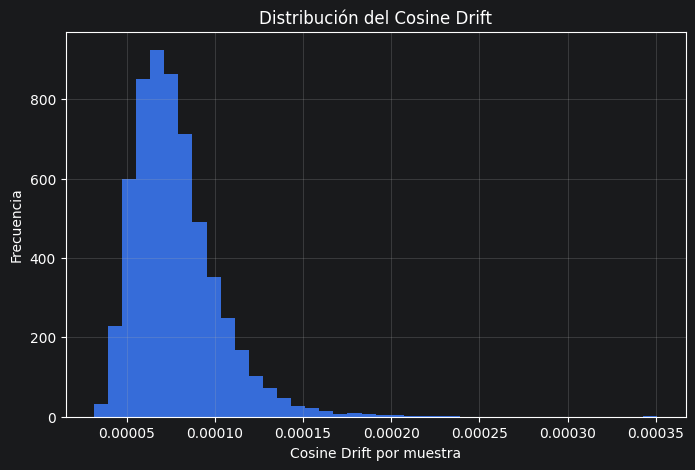

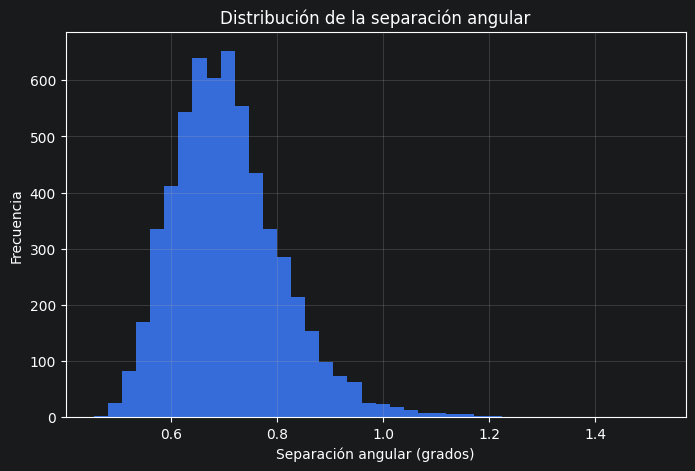

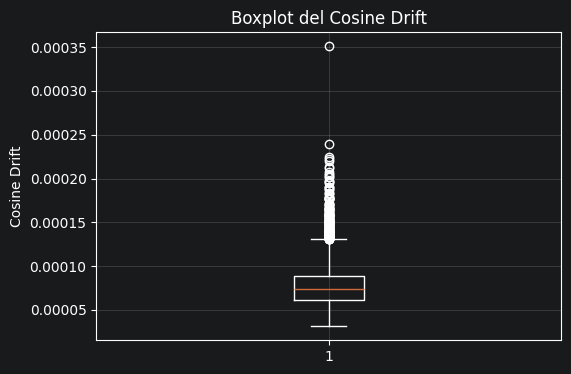

In [15]:
# -----------------------------------
# 4. Histograma del Cosine Drift
# -----------------------------------
plt.figure(figsize=(8, 5))
plt.hist(cos_drift, bins=40)
plt.xlabel("Cosine Drift por muestra")
plt.ylabel("Frecuencia")
plt.title("Distribución del Cosine Drift")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------------
# 5. Histograma del ángulo
# -----------------------------------
plt.figure(figsize=(8, 5))
plt.hist(angle_deg, bins=40)
plt.xlabel("Separación angular (grados)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la separación angular")
plt.grid(alpha=0.3)
plt.show()



plt.figure(figsize=(6, 4))
plt.boxplot(cos_drift, vert=True)
plt.ylabel("Cosine Drift")
plt.title("Boxplot del Cosine Drift")
plt.grid(alpha=0.3)
plt.show()

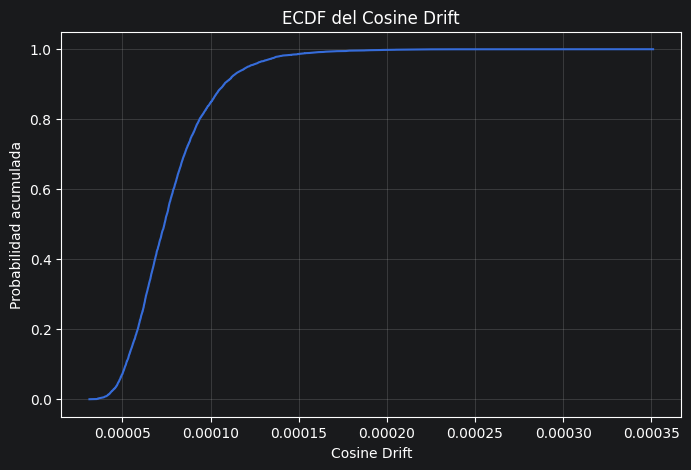


=== Top 10 muestras con mayor Cosine Drift ===
01. idx= 620 | drift=0.000351 | cos=0.999649 | angulo_deg=1.518009
02. idx=1276 | drift=0.000239 | cos=0.999761 | angulo_deg=1.252421
03. idx=2990 | drift=0.000225 | cos=0.999775 | angulo_deg=1.215631
04. idx= 612 | drift=0.000223 | cos=0.999777 | angulo_deg=1.209175
05. idx=3911 | drift=0.000220 | cos=0.999780 | angulo_deg=1.201708
06. idx= 551 | drift=0.000213 | cos=0.999787 | angulo_deg=1.181840
07. idx=5361 | drift=0.000212 | cos=0.999788 | angulo_deg=1.179354
08. idx= 849 | drift=0.000208 | cos=0.999792 | angulo_deg=1.168519
09. idx=3029 | drift=0.000205 | cos=0.999795 | angulo_deg=1.160958
10. idx=5378 | drift=0.000204 | cos=0.999796 | angulo_deg=1.158596

=== Top 10 muestras con menor Cosine Drift ===
01. idx=1312 | drift=0.000031 | cos=0.999969 | angulo_deg=0.453703
02. idx=2105 | drift=0.000034 | cos=0.999966 | angulo_deg=0.470638
03. idx=1712 | drift=0.000034 | cos=0.999966 | angulo_deg=0.474778
04. idx= 911 | drift=0.000036 | c

In [16]:
x = np.sort(cos_drift)
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.xlabel("Cosine Drift")
plt.ylabel("Probabilidad acumulada")
plt.title("ECDF del Cosine Drift")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------------
# 8. Ver muestras con mayor drift
# -----------------------------------
top_k = 10
top_idx = np.argsort(cos_drift)[-top_k:][::-1]

print(f"\n=== Top {top_k} muestras con mayor Cosine Drift ===")
for rank, idx in enumerate(top_idx, start=1):
    print(
        f"{rank:02d}. idx={idx:4d} | "
        f"drift={cos_drift[idx]:.6f} | "
        f"cos={cos_sim[idx]:.6f} | "
        f"angulo_deg={angle_deg[idx]:.6f}"
    )

# -----------------------------------
# 9. Ver muestras con menor drift
# -----------------------------------
low_idx = np.argsort(cos_drift)[:top_k]

print(f"\n=== Top {top_k} muestras con menor Cosine Drift ===")
for rank, idx in enumerate(low_idx, start=1):
    print(
        f"{rank:02d}. idx={idx:4d} | "
        f"drift={cos_drift[idx]:.6f} | "
        f"cos={cos_sim[idx]:.6f} | "
        f"angulo_deg={angle_deg[idx]:.6f}"
    )